# AIS 5 Modeling checkpoint demo

Self-contained walkthrough of the shared infrastructure powering all three modeling tasks.

**No GPU, no network, no dataset download** — everything below runs locally on a laptop CPU. The actual model inference and LoRA training happens on Colab (see `00_baseline_qwen_screenspot_v2.ipynb` and the three task notebooks).

In [1]:
import ais5
print(f'ais5 v{ais5.__version__}')

ais5 v0.1.0


## 1. Model registry

Every model in the comparison is registered in one place. Importing the registry does **not** import torch or transformers — those are pulled in only when you instantiate a model. Keeps notebook startup fast on CPU.

In [2]:
import pandas as pd
from ais5.models import list_models

pd.DataFrame([
    {'name': m.name, 'family': m.family, 'params (B)': m.param_count_b, 'HF id': m.hf_id}
    for m in list_models()
])

,name,family,params (B),HF id
0,qwen2.5-vl-3b,generalist,3.0,Qwen/Qwen2.5-VL-3B-Instruct
1,qwen2.5-vl-7b,generalist,7.0,Qwen/Qwen2.5-VL-7B-Instruct
2,paligemma-3b,generalist,3.0,google/paligemma-3b-mix-448
3,os-atlas-4b,specialist,4.0,OS-Copilot/OS-Atlas-Pro-4B
4,showui-2b,specialist,2.0,showlab/ShowUI-2B
5,ferret-ui-lite-3b,specialist,3.0,apple/Ferret-UI-Lite-3B


## 2. Unified click-action parser

Each model speaks a different output dialect. `ais5.prompt.parse_click` normalizes them all into a single `(x, y)` point, so the eval harness doesn't care which model produced the response.

In [3]:
from ais5.prompt.action import parse_click

cases = [
    ('Qwen2.5-VL',     '<click>423, 167</click>',                          None),
    ('OS-Atlas',       'The save icon is located at (256, 512).',          None),
    ('ShowUI (JSON)',  '{"action": "click", "x": 80, "y": 240}',           None),
    ('PaliGemma',      '<loc0512><loc0768>',                               (1024, 1024)),
    ('Box centroid',   '<box>100, 200, 300, 400</box>',                    None),
    ('Unparseable',    'no idea where to click',                           None),
]

rows = []
for name, text, size in cases:
    p = parse_click(text, image_size=size)
    rows.append({'dialect': name, 'parser': p.parser, 'point': p.point})
pd.DataFrame(rows)

,dialect,parser,point
0,Qwen2.5-VL,qwen-click,"(423.0, 167.0)"
1,OS-Atlas,pixel-tuple,"(256.0, 512.0)"
2,ShowUI (JSON),json-object,"(80.0, 240.0)"
3,PaliGemma,paligemma-loc,"(768.5, 512.5)"
4,Box centroid,box-tag,"(200.0, 300.0)"
5,Unparseable,none,None


## 3. End-to-end eval flow with a mock model

We replace the actual VLM with a deterministic stand-in to demonstrate the eval pipeline. The same `evaluate_model` runner is used by every task notebook on Colab — only the model object changes.

In [4]:
from PIL import Image
from ais5.data.types import GroundingSample
from ais5.eval import evaluate_model, by_ui_type, by_target_size
from ais5.eval.breakdown import by_target_type
from ais5.models.base import GUIModel, ModelOutput
from ais5.prompt.action import ParsedAction

class MockModel(GUIModel):
    name = 'mock-3b'; param_count_b = 3.0; family = 'generalist'
    def __init__(self): self.calls = 0
    def predict(self, image, instruction, **kw):
        self.calls += 1
        x, y = (50.0, 50.0) if self.calls % 2 else (999.0, 999.0)
        return ModelOutput(text=f'<click>{x}, {y}</click>',
                           parsed=ParsedAction(point=(x, y), parser='mock'))

img = Image.new('RGB', (1000, 1000), color='white')
samples = [
    GroundingSample(
        image=img, instruction=f'click element {i}',
        bbox=(0, 0, 100, 100), image_size=(1000, 1000),
        benchmark='screenspot-v2',
        target_type='icon' if i % 2 else 'text',
        ui_type=['web', 'desktop', 'mobile'][i % 3],
        sample_id=str(i),
    )
    for i in range(15)
]

run = evaluate_model(MockModel(), samples, benchmark='screenspot-v2', progress=False)
print(f'accuracy = {run.accuracy:.3f}  (n={len(run.results)})')

accuracy = 0.533  (n=15)


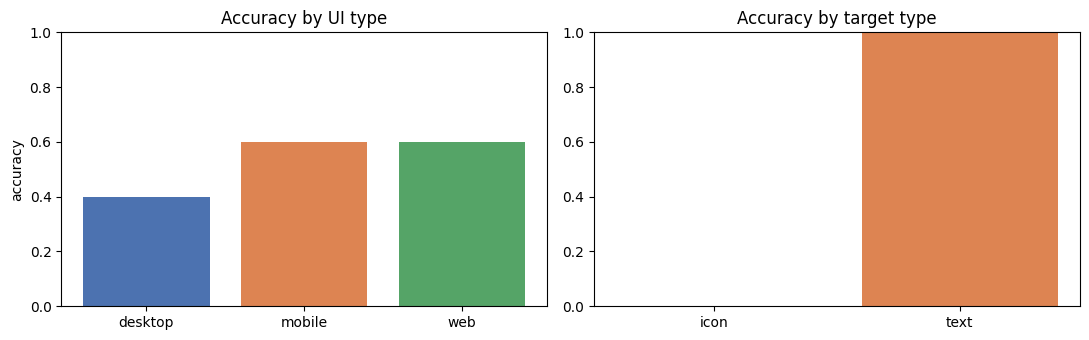

In [5]:
import matplotlib.pyplot as plt

by_ui = by_ui_type(run.results)
by_type = by_target_type(run.results)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(by_ui['ui'], by_ui['accuracy'], color=['#4C72B0', '#DD8452', '#55A467'])
axes[0].set_title('Accuracy by UI type'); axes[0].set_ylabel('accuracy'); axes[0].set_ylim(0, 1)
axes[1].bar(by_type['type'], by_type['accuracy'], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Accuracy by target type'); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 4. Pareto front (Task 3 output preview)

Final shape of the Task 3 deliverable: latency-vs-accuracy and VRAM-vs-accuracy fronts across model × quantization combinations. Numbers below are illustrative — real measurements come from the Colab runs.

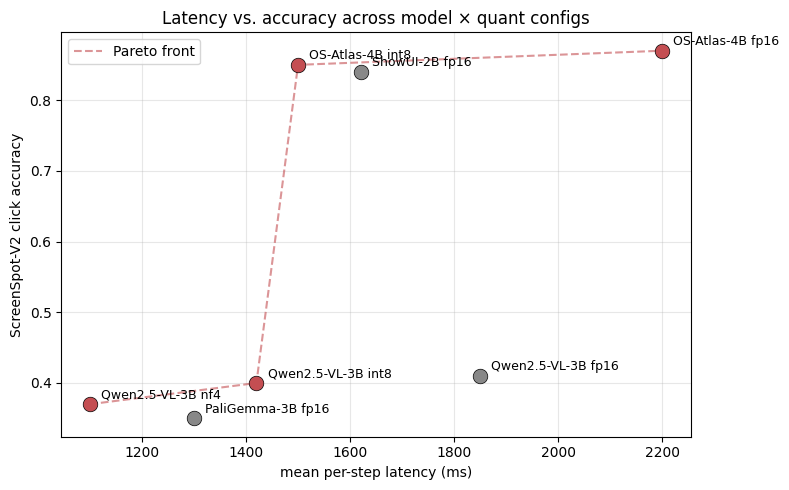

In [6]:
from ais5.bench import ParetoPoint, pareto_front

pts = [
    ParetoPoint(label='Qwen2.5-VL-3B fp16',  accuracy=0.41, cost=1850),
    ParetoPoint(label='Qwen2.5-VL-3B int8',  accuracy=0.40, cost=1420),
    ParetoPoint(label='Qwen2.5-VL-3B nf4',   accuracy=0.37, cost=1100),
    ParetoPoint(label='PaliGemma-3B fp16',   accuracy=0.35, cost=1300),
    ParetoPoint(label='ShowUI-2B fp16',      accuracy=0.84, cost=1620),
    ParetoPoint(label='OS-Atlas-4B fp16',    accuracy=0.87, cost=2200),
    ParetoPoint(label='OS-Atlas-4B int8',    accuracy=0.85, cost=1500),
]
front = pareto_front(pts)
front_set = {p.label for p in front}

fig, ax = plt.subplots(figsize=(8, 5))
for p in pts:
    color = '#C44E52' if p.label in front_set else '#888'
    ax.scatter(p.cost, p.accuracy, s=110, color=color, edgecolor='black', linewidth=0.5, zorder=3)
    ax.annotate(p.label, (p.cost, p.accuracy), xytext=(8, 4), textcoords='offset points', fontsize=9)
ax.plot([p.cost for p in front], [p.accuracy for p in front],
        '--', color='#C44E52', alpha=0.6, label='Pareto front')
ax.set_xlabel('mean per-step latency (ms)')
ax.set_ylabel('ScreenSpot-V2 click accuracy')
ax.set_title('Latency vs. accuracy across model × quant configs')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Crop-then-click geometry (Task 2 building block)

A two-stage "glance-then-focus" wrapper that any `GUIModel` can be plugged into. Verifies the math: stage 1 picks a coarse point, stage 2 refines on a crop, the result is translated back to original-image coordinates.

In [7]:
from ais5.tile import crop_then_click, CropConfig

class StagedFake(GUIModel):
    name = 'staged'; param_count_b = 0.0; family = 'mock'
    def __init__(self, points): self._q = list(points)
    def predict(self, image, instruction, **kw):
        return ModelOutput(text='', parsed=ParsedAction(point=self._q.pop(0), parser='fake'))

image = Image.new('RGB', (1000, 1000))
model = StagedFake([(700, 700), (50, 50)])  # coarse near (700,700), refined (50,50) inside crop
out = crop_then_click(model, image, 'click', cfg=CropConfig(crop_size=200))
print(f'final point  = {out.parsed.point}')
print(f'crop box     = {out.metadata["crop_box"]}')
print(f'coarse point = {out.metadata["coarse_point"]}')

final point  = (650, 650)
crop box     = (600, 600, 800, 800)
coarse point = (700, 700)


## What runs on Colab next

| Notebook | Owner | Hypothesis | Status |
|---|---|---|---|
| `00_baseline_qwen_screenspot_v2.ipynb` | shared | sanity-check the harness | ready |
| `01_task1_lora_adaptation.ipynb` | Shanmuga | H1 — LoRA closes V2 gap | scaffold |
| `02_task2_resolution_crop.ipynb` | Yiwei | H2 — crop-then-click recovers Pro | scaffold |
| `03_task3_efficiency_quant.ipynb` | Ali | H3 — W4A8 -35% latency, <3 pp drop | scaffold |